# Fingerprint Enhancement — Canny Edge Detection
**Project:** Signal & Image Processing Mini-Project  
**Method:** Canny Edge Detection with Morphological Processing  
**Dataset:** FVC2000 DB1_B (`.tif` fingerprint images)

## Stage 1 — Import Libraries & Load Image

Image loaded successfully. Shape: (374, 388), dtype: uint8


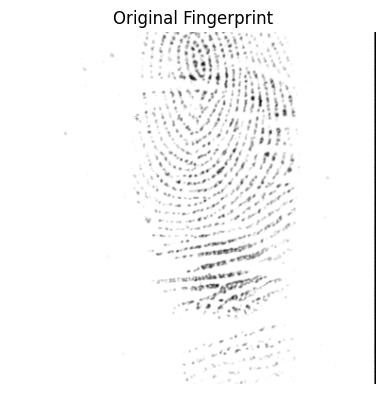

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

# ── Path: place fingerprints folder next to this notebook ──────────────────
IMAGE_PATH = os.path.join("fingerprints", "fingerprints", "DB1_B", "109_6.tif")

# Load the image in grayscale (fingerprints are single-channel by nature)
gray = cv.imread(IMAGE_PATH, cv.IMREAD_GRAYSCALE)

if gray is None:
    raise FileNotFoundError(
        f"Image not found at '{IMAGE_PATH}'. "
        "Make sure the 'fingerprints/DB1_B/' folder is in the same directory as this notebook."
    )

print(f"Image loaded successfully. Shape: {gray.shape}, dtype: {gray.dtype}")
plt.figure(figsize=(4, 4))
plt.imshow(gray, cmap='gray')
plt.title("Original Fingerprint")
plt.axis('off')
plt.tight_layout()
plt.show()


## Stage 2 — Noise Removal
A **Median filter** removes salt-and-pepper noise without blurring edges.  
A **Gaussian filter** then smooths remaining high-frequency noise.

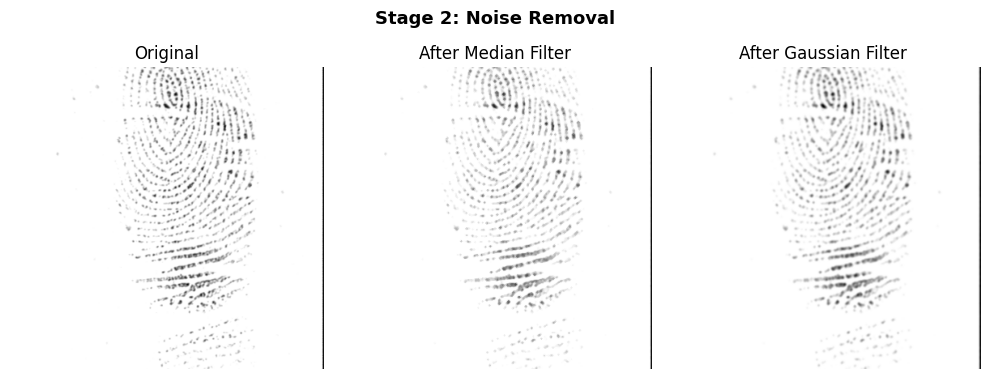

In [8]:
# Step 2a: Median blur — replaces each pixel with the median of its neighbourhood
#          Kernel size 3 preserves ridge edges while removing impulse noise
median_filtered = cv.medianBlur(gray, 3)

# Step 2b: Gaussian blur — further smooths without creating false edges
gaussian_filtered = cv.GaussianBlur(median_filtered, (3, 3), 0)

plt.figure(figsize=(10, 4))
for idx, (img, title) in enumerate([(gray, "Original"),
                                     (median_filtered, "After Median Filter"),
                                     (gaussian_filtered, "After Gaussian Filter")], 1):
    plt.subplot(1, 3, idx)
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.suptitle("Stage 2: Noise Removal", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Stage 3 — Contrast Enhancement
**Histogram Equalization** redistributes pixel intensities for uniform contrast.  
**Power-Law (Gamma) correction** (γ = 0.5) brightens darker ridge areas.

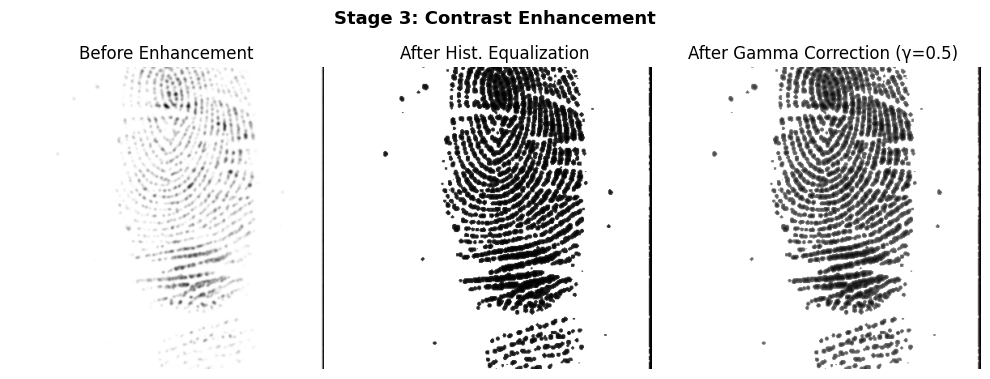

In [9]:
# Step 3a: Histogram equalization — spreads intensity values across [0, 255]
equalized = cv.equalizeHist(gaussian_filtered)

# Step 3b: Power-law (gamma) correction with gamma = 0.5
#          gamma < 1 brightens the image; helps reveal faint ridges
gamma = 0.5
power_law = np.power(equalized / 255.0, gamma)   # normalise → apply gamma
power_law = np.uint8(power_law * 255)              # scale back to uint8

plt.figure(figsize=(10, 4))
for idx, (img, title) in enumerate([(gaussian_filtered, "Before Enhancement"),
                                     (equalized,         "After Hist. Equalization"),
                                     (power_law,         "After Gamma Correction (γ=0.5)")], 1):
    plt.subplot(1, 3, idx)
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.suptitle("Stage 3: Contrast Enhancement", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Stage 4 — Canny Edge Detection
Canny detects the boundaries of fingerprint ridges using gradient magnitude and direction. The low threshold (50) and high threshold (150) follow the 1:3 ratio recommended by Canny (1986).

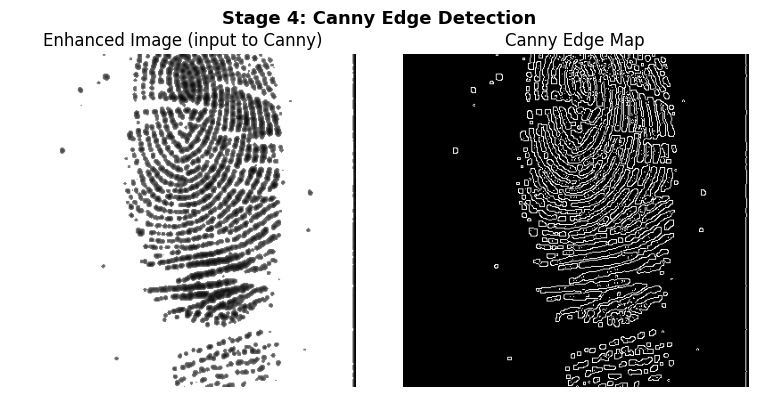

In [10]:
# Canny edge detector — two-threshold approach
# low=50  : pixels below this are suppressed
# high=150: pixels above this are definitely edges; pixels in between depend on connectivity
canny_edges = cv.Canny(power_law, 50, 150)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(power_law, cmap='gray')
plt.title("Enhanced Image (input to Canny)")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(canny_edges, cmap='gray')
plt.title("Canny Edge Map")
plt.axis('off')
plt.suptitle("Stage 4: Canny Edge Detection", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Stage 5 — Morphological Dilation
Dilation with a 3×3 elliptical kernel connects broken ridge segments caused by gaps in the edge map.

Final output saved as 'canny_final_output.tif'


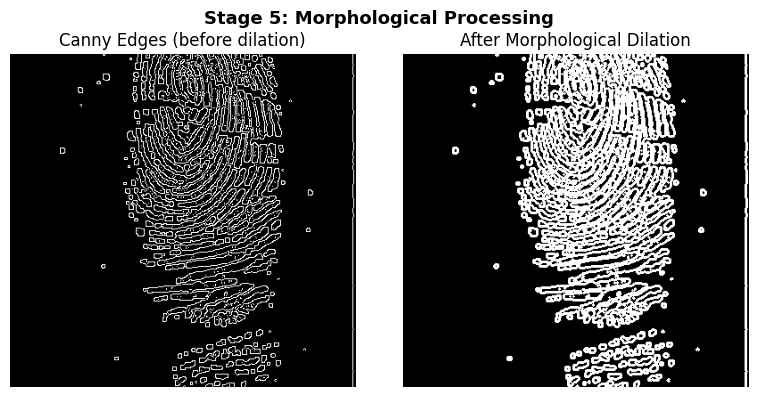

In [11]:
# Elliptical structuring element — better suited to curved fingerprint ridges than a square
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3))

# Single dilation iteration: closes small gaps without over-thickening ridges
dilated = cv.dilate(canny_edges, kernel, iterations=1)

# Save the final output
cv.imwrite("canny_final_output.tif", dilated)
print("Final output saved as 'canny_final_output.tif'")

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(canny_edges, cmap='gray')
plt.title("Canny Edges (before dilation)")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(dilated, cmap='gray')
plt.title("After Morphological Dilation")
plt.axis('off')
plt.suptitle("Stage 5: Morphological Processing", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Full Pipeline Summary

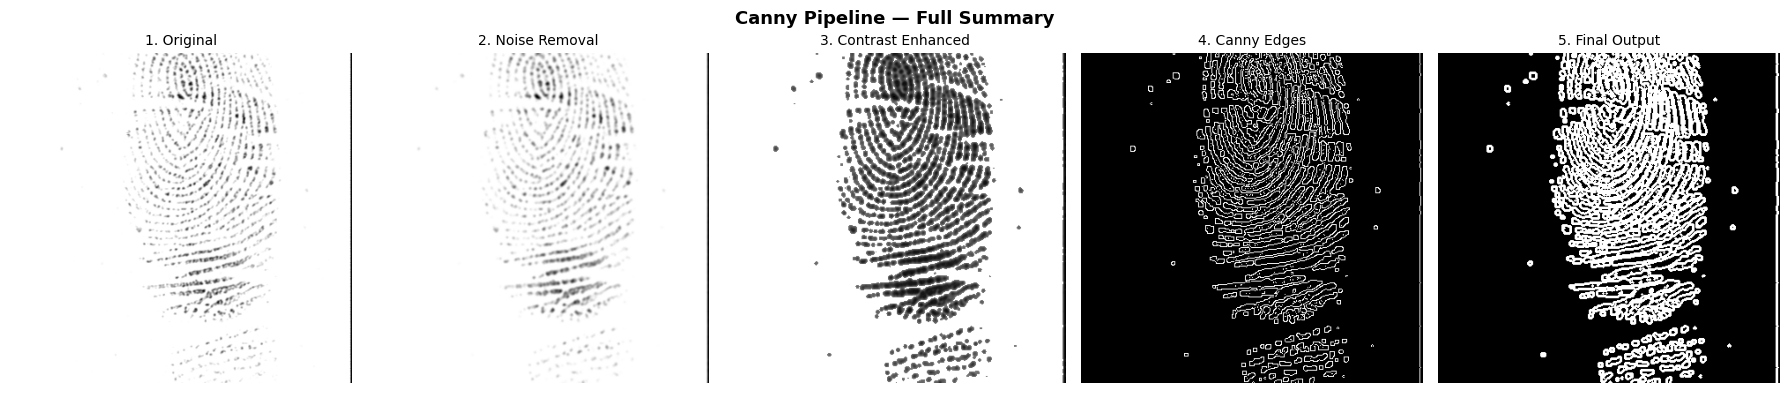

In [12]:
stages = [
    (gray,           "1. Original"),
    (gaussian_filtered, "2. Noise Removal"),
    (power_law,      "3. Contrast Enhanced"),
    (canny_edges,    "4. Canny Edges"),
    (dilated,        "5. Final Output"),
]

plt.figure(figsize=(18, 4))
for i, (img, title) in enumerate(stages, 1):
    plt.subplot(1, 5, i)
    plt.imshow(img, cmap='gray')
    plt.title(title, fontsize=10)
    plt.axis('off')
plt.suptitle("Canny Pipeline — Full Summary", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Histogram Comparison: Original vs Final Output

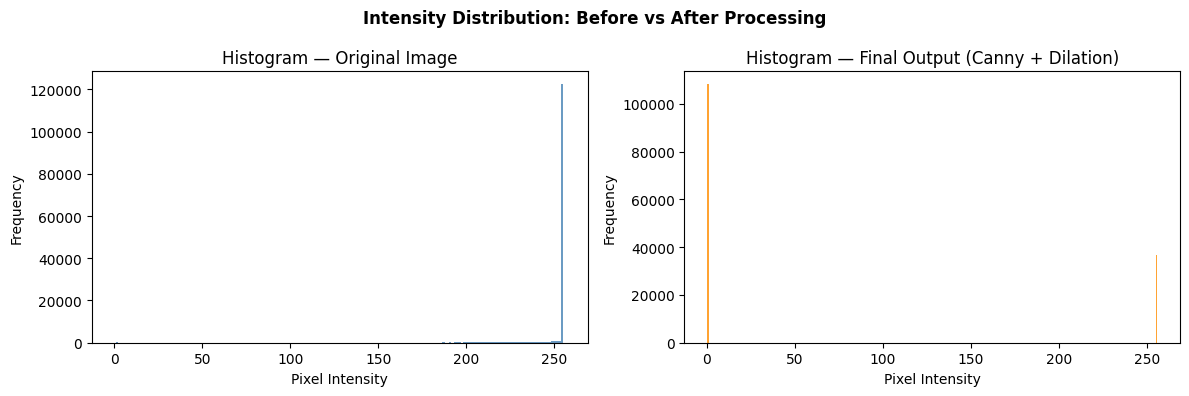

Note: The final histogram shows a bimodal distribution — black background (0) and white ridge edges (255) — confirming successful binarisation.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(gray.ravel(), bins=256, range=[0, 256], color='steelblue', alpha=0.8)
axes[0].set_title("Histogram — Original Image")
axes[0].set_xlabel("Pixel Intensity")
axes[0].set_ylabel("Frequency")

axes[1].hist(dilated.ravel(), bins=256, range=[0, 256], color='darkorange', alpha=0.8)
axes[1].set_title("Histogram — Final Output (Canny + Dilation)")
axes[1].set_xlabel("Pixel Intensity")
axes[1].set_ylabel("Frequency")

plt.suptitle("Intensity Distribution: Before vs After Processing", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print("Note: The final histogram shows a bimodal distribution — black background (0) "
      "and white ridge edges (255) — confirming successful binarisation.")
